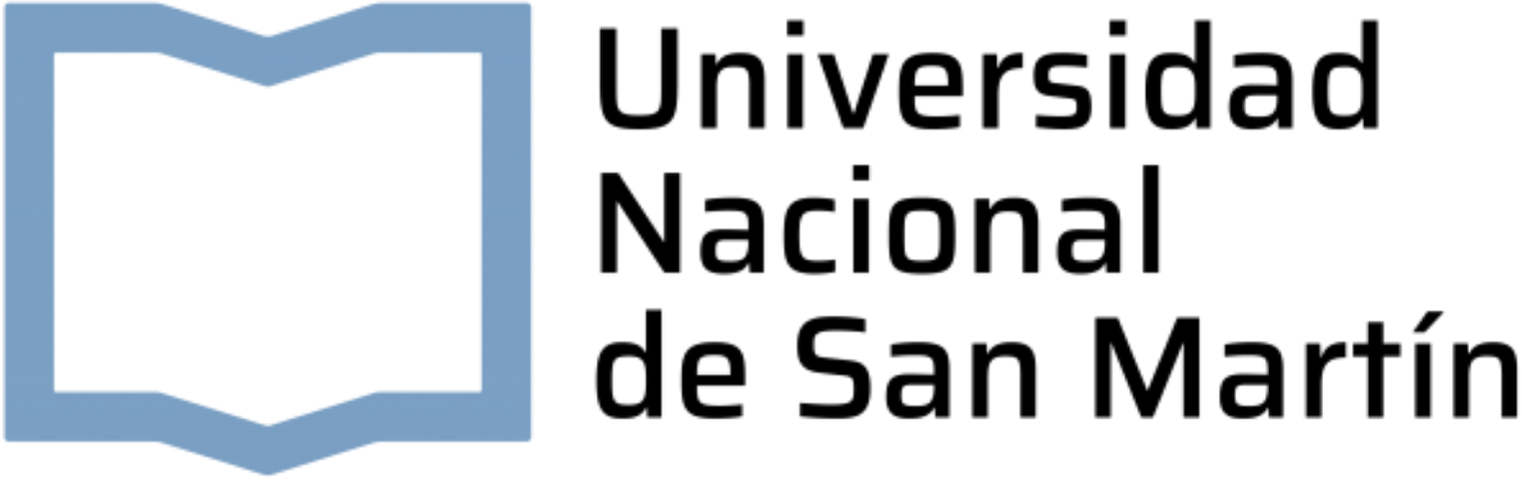

# TS1 Síntesis y operaciones de señales 
# Cristóbal Contador

**En esta practica se hizo un generador de señales en Python usando las librerias de Numpy y Scipy, buscamos sintetizar y analizar las operaciones que podemos hacerle a una señal en tiempo discreto, se trabajó con señales sinuoidiales, ruido normal, ruido uniforme, pulsos rectangulares y señal de frecuencia variable.
A continuacion se analizara cada una de las señales generadas asi como sus transformadas de fourier.**

En este trabajo buscabamos hacer un generador de señal de N=1000 muestras, a continuacion haremos los primeros llamados a funciones asi como las primeras declaraciones de variables.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal #esto lo pongo para las cuadradas
print("importado") #esto se lo agrego pq asi aca en el jupyter puedo ir viendo si me importo bien

N = 1000 # numero de muestras

#de aqui para abajo recien edito
vmax = 1 #amplitud maxima
dc = 0 # desplazamiento
f = 2000 #frecuencia
ph = 0 #desfasaje
print("señal fijada")

importado
señal fijada


Para el primer inciso buscamos hacer una señal sinusoidal de 2KHz que tenga al menos 10 puntos por período y visualizar su modulo de la transformadad de Fourier. Para esto primero haremos el calculo de nuestra fs minima. $$ f_s \geq 10 \cdot f = 10 \cdot 2000\,\text{Hz} = 20000\,\text{Hz} $$
Ya teniendo esto definido terminamos de definir nuestra funcion generadora y calculamos su FFT, luego aplicaremos np.fft.fftshift para que el grafico nos quede centrado y asi poder visualizarlo de manera mas intuitiva.

Text(0, 0.5, 'espectro del modulo')

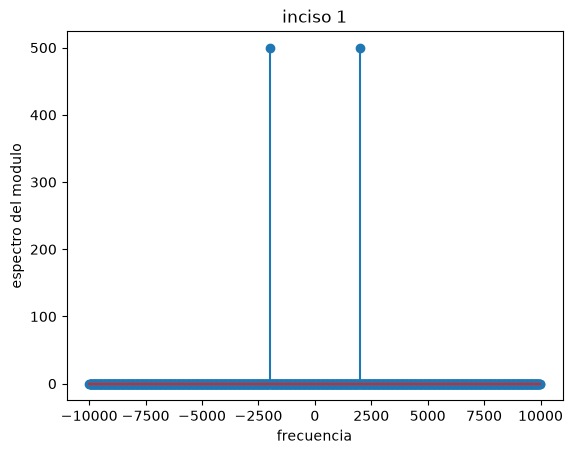

In [7]:
fs = 20000 #frecuencia de muestreo

def mi_funcion_sen():

    
    tt = np.arange(N)/fs
    xx = (vmax * np.sin(2 * np.pi * f * tt + ph)) +dc
    return (tt,xx)

tt, xx = mi_funcion_sen()

fft = np.fft.fft(xx)
ffts = np.fft.fftshift(fft)
modulo = np.abs(ffts)
ff = np.fft.fftfreq(N, 1/fs)
ffs = np.fft.fftshift(ff)

plt.figure()
plt.stem(ffs, modulo)
plt.title("inciso 1")
plt.xlabel("frecuencia")
plt.ylabel("espectro del modulo")

En el grafico del modulo vs frecuencia de la fft podemos ver como ambas delatas nos quedaron perectamente simetricas en -2000Hz y +2000Hz, esto se debe a que nuestra señal es real, por propiedad de la DFT el espectro de una señal real es conjugado simetrico, osea que el modulo es una funcion par.
El espectro se ve perfectamente limpio debido a que nuestra frecuencia (f=2000H) es un multiplo de la resolucion espectral (2000Hz/20Hz), entonces la energia cae exacta.

Para el segundo inciso se nos pide que desfasemos la señal en $\pi/2$ y que le pongamos una potencia media de 2W.
Para el desfasaje simplemente cambiamos el ph de nuestro generador de señal por $\pi/2$.
Para la potencia media lo que hicimos es que ya que el vmax es el unico parametro del codigo que podemos modificar para lograr la potencia media, hay que recordarnos que la potencia media no escala linealmente con la amplitud, sino que escala al cuadrado.
Este calculo lo hicimos con np.sqrt( 2 / (np.sum(xx**2) / N) ) este codigo lo que hace es encontrarnos el factor de escala, que es el que tenemos que multiplicar por vmax para llegar a nuestra potencia media final de 2W.

el valor de potencial del inciso 2 medido con el tiempo es de: 2.0 y por frecuencia es: 2.0000000000000004


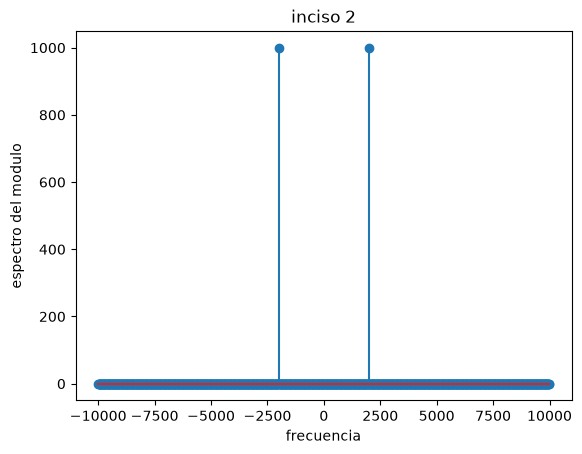

In [9]:
ph = np.pi/2
vmax = vmax * np.sqrt( 2 / (np.sum(xx**2) / N) )

tt, xx = mi_funcion_sen()

fft = np.fft.fft(xx)
ffts = np.fft.fftshift(fft)
modulo = np.abs(ffts)
ff = np.fft.fftfreq(N, 1/fs)
ffs = np.fft.fftshift(ff)

plt.figure()
plt.stem(ffs, modulo)
plt.title("inciso 2")
plt.xlabel("frecuencia")
plt.ylabel("espectro del modulo")

pot_t = np.sum(xx**2) / N
pot_f = np.sum(np.abs(fft)**2) / (N**2)
print("el valor de potencial del inciso 2 medido con el tiempo es de:", pot_t, "y por frecuencia es:",pot_f)


En el grafico podemos analizar que el desfase es invisible en el grafico del modulo, ya que el modulo solo mide la energia, no hacia donde apunta, tambien podemos observar que el valor real de nuestros picos es el doble que el anterior, ya que llegamos al doble de la amplitud, lo cual equivale a 4 veces mas potencia.
Tambien se agrego al final del codigo un print que nos dejo comprobar si el teorema de Parseval se cumplia en nuestro codigo, el teorema nos dice:
$$
E_x = \sum_{n=0}^{N-1} |x[n]|^2
= \frac{1}{N}\sum_{k=0}^{N-1} |X[k]|^2
$$
En nuestro codigo lo dividimos una vez más por N ya que estamos buscando calcular la potencia media, no la energia.
Por los resultados del print podemos comprobar que si que se cumple el teorema como esperabamos teoricamente.

Para nuestro tercer inciso se nos pide una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W. Para poner nuestra varianza de 0.1W simplemente definimos la varianza con un valor de 0.1W, y para que nuestro valor medio sea 0 lo declaramos como 0 dentro de nuestra funcion np.random.normal.

Text(0, 0.5, 'espectro del modulo')

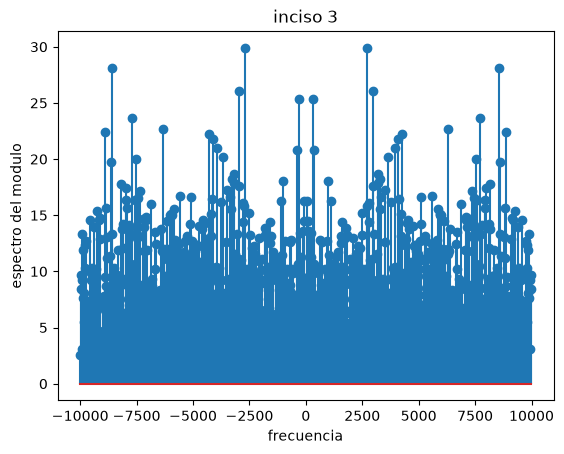

In [13]:
var = 0.1

ruido = np.random.normal(0, np.sqrt(var), N)

fft = np.fft.fft(ruido)
ffts = np.fft.fftshift(fft)
modulo = np.abs(ffts)
ff = np.fft.fftfreq(N, 1/fs)
ffs = np.fft.fftshift(ff)

plt.figure()
plt.stem(ffs, modulo)
plt.title("inciso 3")
plt.xlabel("frecuencia")
plt.ylabel("espectro del modulo")

Como podemos ver en nuestro grafico es simplemente una distribucion aleatoria que no puede ser identificada con su grafico de modulo vs frecuencia, ya que solo vemos valores de energia.

Para nuestro cuarto inciso se nos pide una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. Para poner varianza de 0.1W simplemente definimos la varianza, esto lo hicimos en el inciso anterior por lo cual no lo declararemos de vuelta y luego la usamos para el calculo de los rangos.
Para incluir que el valor medio fuese 0 lo que hicimos fue definir el a (valor minimo) y el b (valor maximo) de nuestra distribucion de la siguiente manera: a = -rango/2, b = rango/2, al hacer esto nuestro valor medio pasa a ser 0V debido a:
$$
\text{Valor Medio} = \frac{-\text{rango}/2 + \text{rango}/2}{2}
= \frac{0}{2}
= 0\,\text{V}
$$
Con esto cumplimos exactamente lo que nos pide la consigna

Text(0, 0.5, 'espectro del modulo')

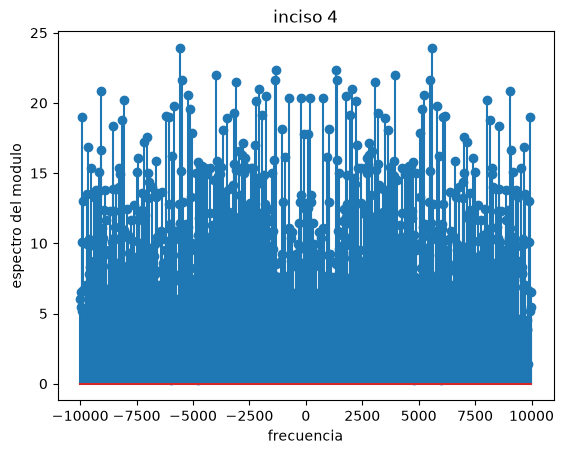

In [14]:
rango = np.sqrt(12 * var)
a = -rango/2
b = rango/2

ruido = np.random.uniform(a, b, N)
fft = np.fft.fft(ruido)
ffts = np.fft.fftshift(fft)
modulo = np.abs(ffts)
ff = np.fft.fftfreq(N, 1/fs)
ffs = np.fft.fftshift(ff)

plt.figure()
plt.stem(ffs, modulo)
plt.title("inciso 4")
plt.xlabel("frecuencia")
plt.ylabel("espectro del modulo")

En el grafico del espectro podemos ver nuevamente algo parecido a nuestro grafico de ruido normal, nuevamente no se puede identificar simplemente con el grafico de su modulo vs frecuencia de la dft, ya que nuevamente vemos los valores de energia.

Para nuestro inciso quinto inciso haremos un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%, esto simplemente lo definimos nuevamente con nuestro np.sqrt(1 / (np.sum(xx**2) / N)) la frecuencia y el ciclo de actividad con duty = 0.5.


el valor de potencial del inciso 5 medido con el tiempo es de: 1.0 y por frecuencia es: 1.0


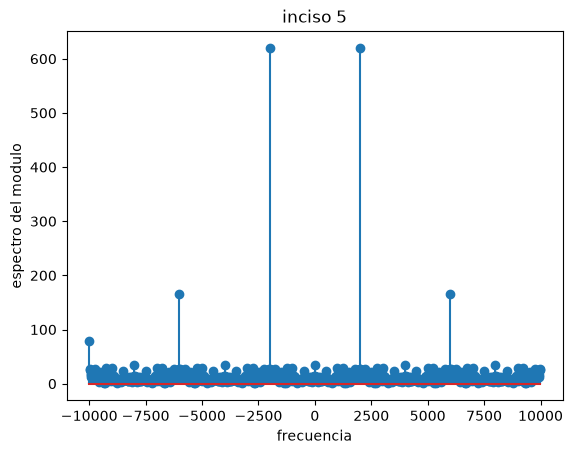

In [16]:
from scipy import signal

xx = signal.square(2 * np.pi * f * tt, duty=0.5)
vmax = np.sqrt(1 / (np.sum(xx**2) / N))

xx = vmax*xx

fft = np.fft.fft(xx)
ffts = np.fft.fftshift(fft)
modulo = np.abs(ffts)
ff = np.fft.fftfreq(N, 1/fs)
ffs = np.fft.fftshift(ff)

plt.figure()
plt.stem(ffs, modulo)
plt.title("inciso 5")
plt.xlabel("frecuencia")
plt.ylabel("espectro del modulo")

pot_t = np.sum(xx**2) / N
pot_f = np.sum(np.abs(fft)**2) / (N**2)

print("el valor de potencial del inciso 5 medido con el tiempo es de:", pot_t, "y por frecuencia es:",pot_f)

En este grafico podemos ver nuestras deltas nuevamente simetricas, pero en este caso tenemos varias deltas, esto se debe a que segun la teoria de Fourier una señal cuadrada esta compuesta por la suma de infinitos senos impares.

Por ultimo se analizo una ultima señal que me parecio interesante, la señal chirp o barrido de frecuencia, que es una señal de frecuencia variable, entonces podremos ver un analisis diferente de su fft.

Text(0, 0.5, 'espectro del modulo')

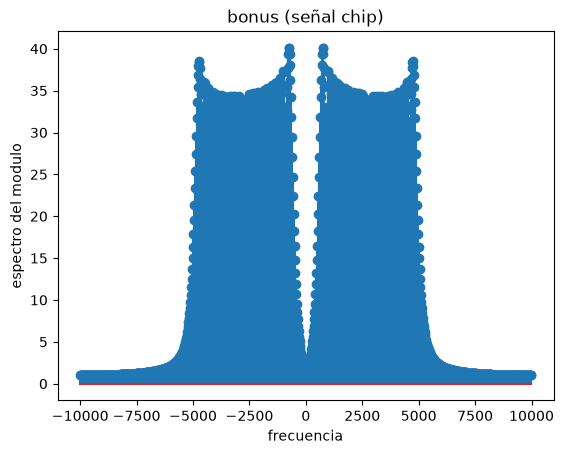

In [17]:
xx = signal.chirp(tt, f0=500, t1=0.05, f1=5000)

fft = np.fft.fft(xx)
ffts = np.fft.fftshift(fft)
modulo = np.abs(ffts)
ff = np.fft.fftfreq(N, 1/fs)
ffs = np.fft.fftshift(ff)

plt.figure()
plt.stem(ffs, modulo)
plt.title("bonus (señal chip)")
plt.xlabel("frecuencia")
plt.ylabel("espectro del modulo")

Como podemos ver en el grafico las deltas ya no estan distanciadas como antes vimos, tambien podemos ver que al ser la señal de esta manera variable de frecuencia no podemos saber simplemente viendo el grafico si la señal empezo de una manera u otra, es un caso muy interesante para ver las limitaciones de la fft.

En conclusion en esta experimentacion logramos ver como los diferentes tipos de señal afectan a como se ve la fft, pudimos ver como algunas cosas como el desfasaje no afecta al modulo de la fft y otras como cambiar la potencia media si que lo hacen, tambien pudimos comprobar en codigo que si se cumpla el Teorema de Parseval en la practica como se cumple en la teoria.